# Data Import, Cleaning and KPI Preparation

**Import libraries**

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load the dataset**

In [45]:
df = pd.read_csv("spotify_dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Basic info and missing values**

In [46]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


**Filtering data**

In [47]:
df = df.dropna()

# Removing extremely short tracks
df = df[df["duration_ms"] >= 30000]

df = df[df["popularity"] > 0]

df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [48]:
df.shape

(97979, 21)

**Convert relevant columns**

In [49]:
# binary encode explicit
df["explicit"] = df["explicit"].astype(int)

# duration in minutes
df["duration_ms"] = df["duration_ms"] / 60000
df.rename(columns={"duration_ms": "duration_min"}, inplace=True)

df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_min,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,3.844433,0,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,2.493500,0,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,3.513767,0,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,3.365550,0,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,3.314217,0,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,6.416650,0,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,6.416667,0,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,4.524433,0,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,4.731550,0,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


**Create target variable for logistic regression**

In [50]:
df["popular"] = (df["popularity"] >= 60).astype(int)
df["popular"] = df["popular"].map({1: "Popular", 0: "Unpopular"})
(df["popular"].value_counts(normalize=True) * 100).round(1)

,proportion
popular,
Unpopular,84.9
Popular,15.1


Explicit tracks

In [51]:
explicit_percentage = (df["explicit"].mean()) * 100
print(f"Percentage of explicit tracks: {explicit_percentage:.1f}%")

Percentage of explicit tracks: 8.6%


**Set features for modelling**

In [52]:
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_min", "explicit", "key", "mode"
]

X = df[features]
y_reg = df["popularity"]
y_clf = df["popular"]

## **Descriptive Analysis (Plots and KPIs)**

**Popularity distribution**

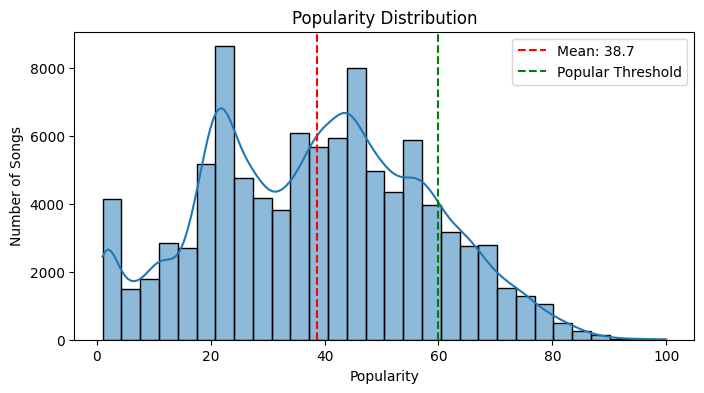

In [53]:
mean_pop = df["popularity"].mean()

plt.figure(figsize=(8,4))
sns.histplot(df["popularity"], kde=True, bins=30)

plt.axvline(mean_pop, color="red", linestyle="--", label=f"Mean: {mean_pop:.1f}")
plt.axvline(60, color="green", linestyle="--", label="Popular Threshold")

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.legend()
plt.show()

**Top 10 popularities by genre**

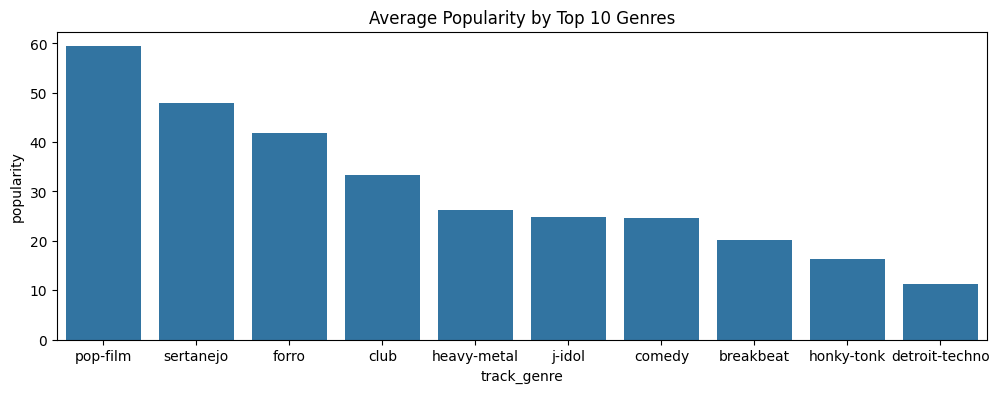

In [54]:
top_genres = df["track_genre"].value_counts().head(10).index
df_top = df[df["track_genre"].isin(top_genres)]
df_top_sorted = df_top.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,4))
sns.barplot(data=df_top_sorted, x="track_genre", y="popularity")
plt.xticks(rotation=0)
plt.title("Average Popularity by Top 10 Genres")
plt.show()

**Correlation heatmap**

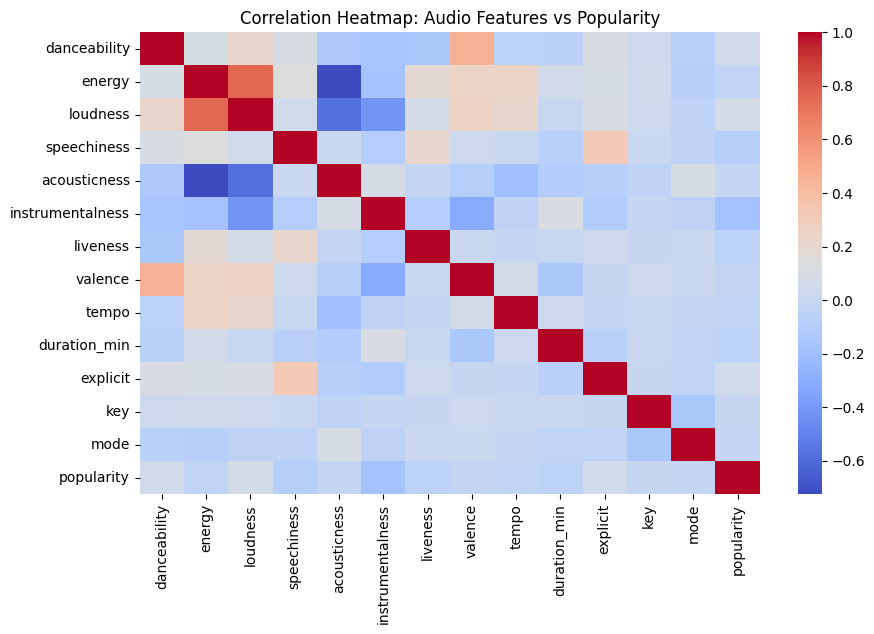

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(df[features + ["popularity"]].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap: Audio Features vs Popularity")
plt.show()

**Popular vs Not Popular**

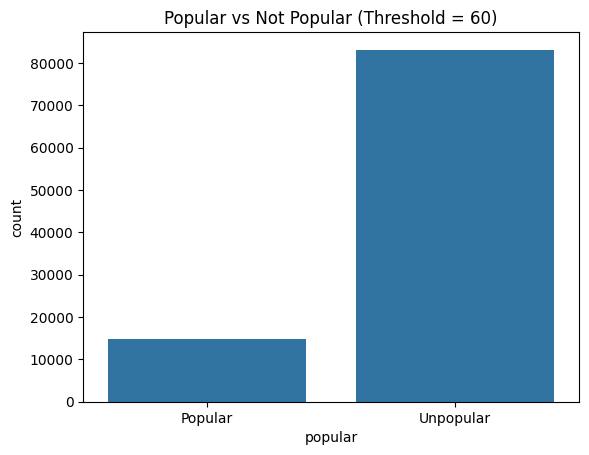

In [56]:
sns.countplot(data=df, x="popular")
plt.title("Popular vs Not Popular (Threshold = 60)")
plt.show()

## **Regression & Logistic Models**

**Train-test split**

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

Linear regression of popularity score

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, y_reg_train)

y_reg_pred = lin_model.predict(X_test)

print("Linear Regression R^2:", r2_score(y_reg_test, y_reg_pred))
print("Linear Regression MSE:", mean_squared_error(y_reg_test, y_reg_pred))

lin_coeff = pd.DataFrame({
    "feature": features,
    "coefficient": lin_model.coef_
})
print(lin_coeff.sort_values("coefficient", ascending=False))

Linear Regression R^2: 0.06667556148357234
Linear Regression MSE: 348.1796204968376
             feature  coefficient
0       danceability     1.284091
10          explicit     1.224764
2           loudness     1.166709
11               key    -0.044658
8              tempo    -0.184874
12              mode    -0.317728
4       acousticness    -0.436552
6           liveness    -0.451253
9       duration_min    -0.777446
1             energy    -1.835896
7            valence    -1.957570
3        speechiness    -2.315817
5   instrumentalness    -3.735655


Logistic regression of Popularity vs Not

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=2000, class_weight='balanced')
log_model.fit(X_train, y_clf_train)

y_clf_pred = log_model.predict(X_test)

print("Logistic regression")
print("Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print(confusion_matrix(y_clf_test, y_clf_pred))
print(classification_report(y_clf_test, y_clf_pred, zero_division=0)) # Getting rid of the warnings

Logistic regression
Accuracy: 0.5509797917942437
[[2132  888]
 [7911 8665]]
              precision    recall  f1-score   support

     Popular       0.21      0.71      0.33      3020
   Unpopular       0.91      0.52      0.66     16576

    accuracy                           0.55     19596
   macro avg       0.56      0.61      0.49     19596
weighted avg       0.80      0.55      0.61     19596



Random Forest of Popularity vs Not

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
rf.fit(X_train, y_clf_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_clf_test, y_pred_rf))
print(confusion_matrix(y_clf_test, y_pred_rf))
print(classification_report(y_clf_test, y_pred_rf, zero_division=0))

Random Forest
Accuracy: 0.921310471524801
[[ 1652  1368]
 [  174 16402]]
              precision    recall  f1-score   support

     Popular       0.90      0.55      0.68      3020
   Unpopular       0.92      0.99      0.96     16576

    accuracy                           0.92     19596
   macro avg       0.91      0.77      0.82     19596
weighted avg       0.92      0.92      0.91     19596



# K-Means Clustering

**Features for clustering**

In [61]:
cluster_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

df_popular = df[df["popularity"] >= 60].copy()

X_cluster = df_popular[cluster_features]

Scaling the features

In [62]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

K-Means with 3 clusters

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_popular["cluster"] = kmeans.fit_predict(X_cluster_scaled)

Describing clusters

In [64]:
cluster_description = df_popular.groupby("cluster")[cluster_features + ["popularity"]].mean()
print(cluster_description)

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.559898  0.418090  -9.901646     0.051502      0.584237   
1            0.505635  0.794261  -5.399274     0.074085      0.071650   
2            0.714355  0.712879  -6.155049     0.095824      0.178028   
3            0.343479  0.141120 -24.098644     0.050743      0.870153   

         instrumentalness  liveness   valence       tempo  popularity  
cluster                                                                
0                0.044998  0.149692  0.353845  113.191069   67.586504  
1                0.062404  0.234820  0.399427  134.466551   68.118630  
2                0.023024  0.157671  0.661088  115.712656   69.509807  
3                0.848997  0.133482  0.172821  101.992217   64.003559  


Songs and popularity in each cluster

In [65]:
print(f"Songs: {df_popular["cluster"].value_counts()}\n")
print(f"Popularity: {df_popular.groupby("cluster")["popularity"].mean()}")

Songs: cluster
2    5812
1    4847
0    3601
3     562
Name: count, dtype: int64

Popularity: cluster
0    67.586504
1    68.118630
2    69.509807
3    64.003559
Name: popularity, dtype: float64


Visualization

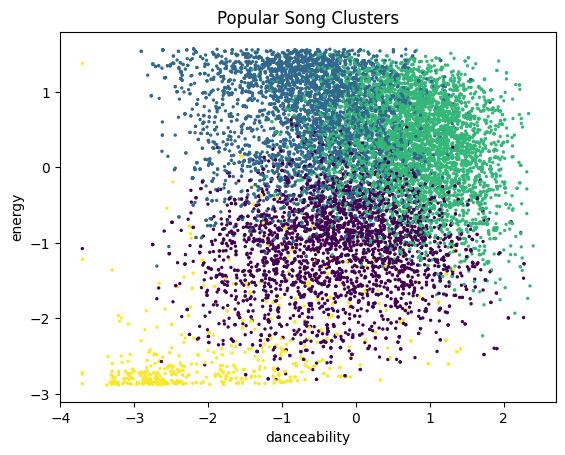

In [66]:
import matplotlib.pyplot as plt

plt.scatter(X_cluster_scaled[:,0], X_cluster_scaled[:,1], c=df_popular["cluster"], cmap='viridis', s=2)
plt.xlabel("danceability")
plt.ylabel("energy")
plt.title("Popular Song Clusters")
plt.show()